In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
df = pd.read_csv("C:/Users/Asus/Desktop/train.csv")

In [18]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## 2. Exploratory Data Analysis

### 2.1 Dataset Overview

In [20]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Shape: (21263, 82)

Column Names:
['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie', 'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density', 'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity', 'gmean_ElectronAffinity', 'wtd_gmean_ElectronAffinity', 'entropy_ElectronAffi

### 2.2 Data Types

In [21]:

print("\nData Types:")
print(df.dtypes)




Data Types:
number_of_elements         int64
mean_atomic_mass         float64
wtd_mean_atomic_mass     float64
gmean_atomic_mass        float64
wtd_gmean_atomic_mass    float64
                          ...   
range_Valence              int64
wtd_range_Valence        float64
std_Valence              float64
wtd_std_Valence          float64
critical_temp            float64
Length: 82, dtype: object


### 2.3 Missing Values

In [22]:

print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64


### 2.4 Duplicates

In [23]:

print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 66


### 2.5 Target Distribution

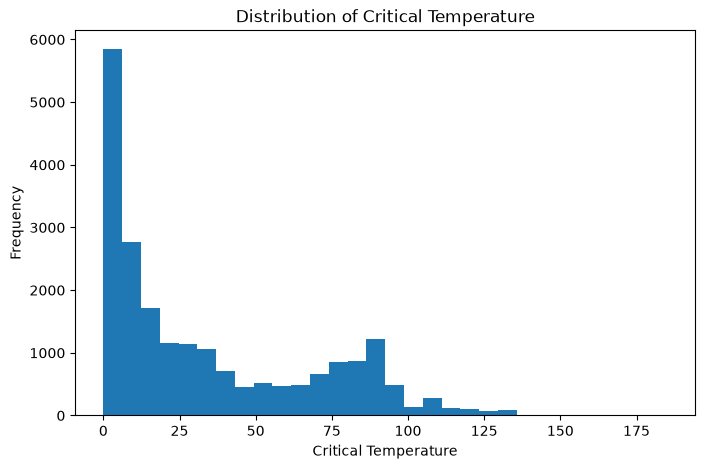

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["critical_temp"], bins=30)
plt.xlabel("Critical Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Critical Temperature")
plt.show()

### 2.6 Feature Distributions

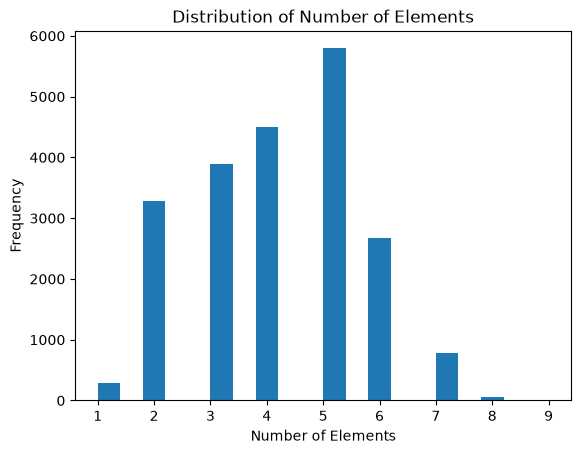

In [44]:
plt.hist(df["number_of_elements"], bins=20)
plt.xlabel("Number of Elements")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Elements")
plt.show()

### 2.7 Correlation Heatmap

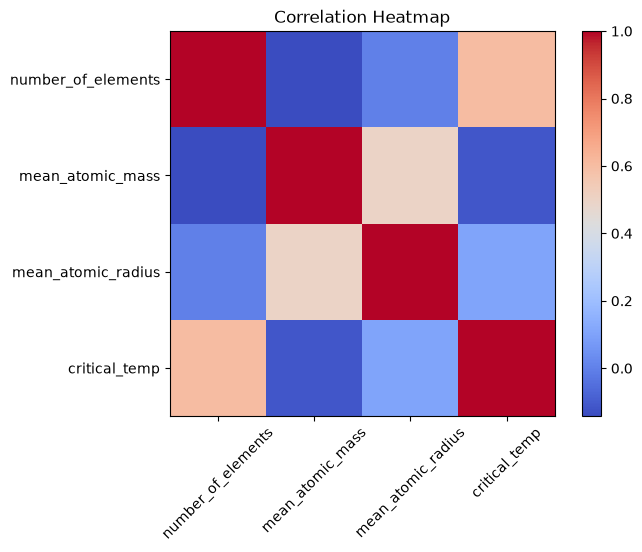

In [27]:
corr = df[["number_of_elements", "mean_atomic_mass", 
           "mean_atomic_radius", "critical_temp"]].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(4), corr.columns, rotation=45)
plt.yticks(range(4), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

### 2.8 Feature vs Target Analysis

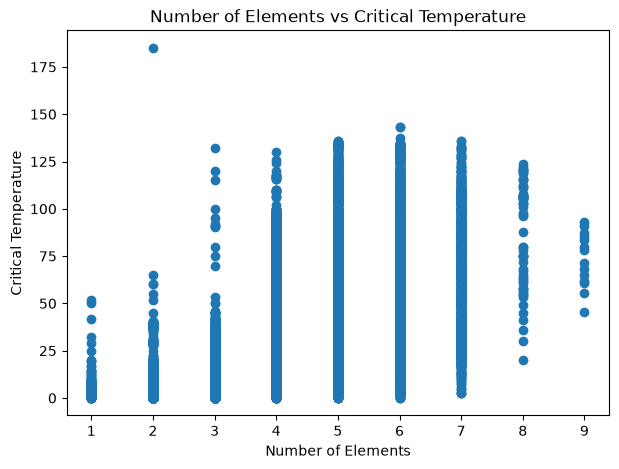

In [28]:
plt.figure(figsize=(7, 5))

plt.scatter(df["number_of_elements"], df["critical_temp"])

plt.xlabel("Number of Elements")
plt.ylabel("Critical Temperature")
plt.title("Number of Elements vs Critical Temperature")

plt.show()

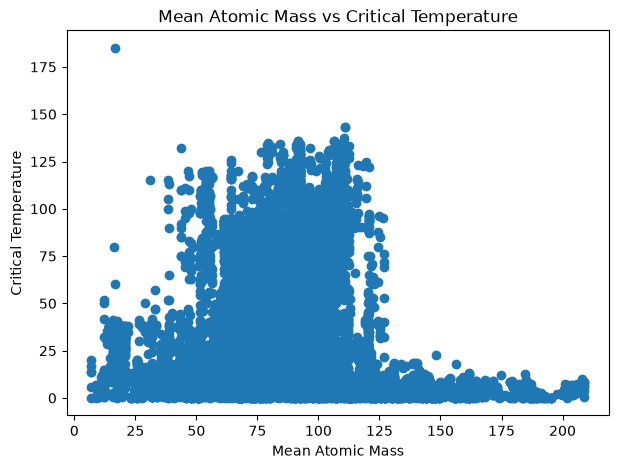

In [29]:
plt.figure(figsize=(7, 5))

plt.scatter(df["mean_atomic_mass"], df["critical_temp"])

plt.xlabel("Mean Atomic Mass")
plt.ylabel("Critical Temperature")
plt.title("Mean Atomic Mass vs Critical Temperature")

plt.show()

### 2.9 EDA Insights

- The number of elements shows different ranges of critical temperature, with higher values of critical temperature mainly observed for samples containing 4 to 7 elements.
- Mean atomic mass shows a non-linear relationship with critical temperature. Higher critical temperatures are mainly concentrated around the middle range of mean atomic mass.
- Some outliers with unusually high critical temperature values can be observed in both plots.
- The scatter plots indicate that a single feature may not be sufficient to predict critical temperature accurately, so multiple features will be used for the regression models.

## 3. Preprocessing & Feature Engineering

### 3.1 Separate Features and Target

In [30]:
X = df.drop("critical_temp", axis=1)
y = df["critical_temp"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (21263, 81)
Target Shape: (21263,)


### 3.2 Handling Missing Values

In [31]:
print("Total Missing Values:", X.isnull().sum().sum())

Total Missing Values: 0


### 3.3 Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17010, 81)
X_test: (4253, 81)
y_train: (17010,)
y_test: (4253,)


### 3.4 Outlier Check

In [33]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((X_train < lower_bound) | (X_train > upper_bound)).sum()

print("Outliers in each feature:")
print(outliers)

Outliers in each feature:
number_of_elements         13
mean_atomic_mass         1336
wtd_mean_atomic_mass      986
gmean_atomic_mass        2666
wtd_gmean_atomic_mass     998
                         ... 
wtd_entropy_Valence         0
range_Valence               0
wtd_range_Valence        1145
std_Valence                38
wtd_std_Valence            18
Length: 81, dtype: int64


### 3.5 Outlier Treatment

In [34]:
# We keep the detected outliers because they may represent
# valid superconducting material properties.

print("Outliers are retained for model training.")

Outliers are retained for model training.


The IQR method was used to identify potential outliers. 
The detected outliers were retained because extreme values may represent valid material properties rather than data-entry errors.

### 3.6 Feature Engineering

In [36]:
X = df.drop("critical_temp", axis=1)
y = df["critical_temp"]

# Create engineered feature
X["mass_per_element"] = X["mean_atomic_mass"] / X["number_of_elements"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (17010, 82)
X_test: (4253, 82)


### 3.7 Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaled Training Data Shape: (17010, 82)
Scaled Testing Data Shape: (4253, 82)


## 4. Regression Models

### 4.1 Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
print("Linear Regression completed.")

Linear Regression completed.


### 4.2 Ridge Regression

In [39]:
from sklearn.linear_model import Ridge
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
print("Ridge Regression completed.")

Ridge Regression completed.


### 4.3 Lasso Regression

In [40]:
from sklearn.linear_model import Lasso
lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
print("Lasso Regression completed.")

Lasso Regression completed.


### 4.4 ElasticNet Regression

In [42]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet()
elastic_model.fit(X_train_scaled, y_train)
y_pred_elastic = elastic_model.predict(X_test_scaled)
print("ElasticNet Regression completed.")

ElasticNet Regression completed.


### 4.5 Polynomial Regression

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Create and train model
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial Regression completed.")
print("Polynomial Training Shape:", X_train_poly.shape)
print("Polynomial Testing Shape:", X_test_poly.shape)

Polynomial Regression completed.
Polynomial Training Shape: (17010, 3486)
Polynomial Testing Shape: (4253, 3486)


### 4.6 Decision Tree Regressor

In [46]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
print("Decision Tree Regression completed.")

Decision Tree Regression completed.


### 4.7 Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest Regression completed.")

Random Forest Regression completed.


### 4.8 Gradient Boosting Regressor

In [48]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
print("Gradient Boosting Regression completed.")

Gradient Boosting Regression completed.


### 4.9 Support Vector Regression

In [49]:
from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
print("SVR completed.")

SVR completed.


### 4.10 KNN Regressor

In [50]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN Regression completed.")

KNN Regression completed.


### 4.11 Model Evaluation

The performance of all regression models is evaluated using R², RMSE, and MAE.

- R² measures how well the model explains the variation in the target.
- RMSE measures the average magnitude of prediction errors, giving more weight to larger errors.
- MAE measures the average absolute prediction error.

Higher R² and lower RMSE and MAE indicate better performance.

In [51]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Store all models and their predictions
results = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Regression": y_pred_poly,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "SVR": y_pred_svr,
    "KNN": y_pred_knn
}

# Calculate evaluation metrics
evaluation_results = []

for model_name, predictions in results.items():
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    evaluation_results.append([
        model_name,
        r2,
        rmse,
        mae
    ])

# Create comparison table
results_df = pd.DataFrame(
    evaluation_results,
    columns=["Model", "R2", "RMSE", "MAE"]
)

# Rank models by R2
results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("Regression Model Comparison:")
display(results_df)

Regression Model Comparison:


,Model,R2,RMSE,MAE
0,Random Forest,0.928985,9.041254,5.107495
1,KNN,0.905292,10.441094,5.905392
2,Decision Tree,0.880686,11.719237,6.071876
3,Gradient Boosting,0.867065,12.370070,8.521780
4,SVR,0.783577,15.783528,10.198247
5,Linear Regression,0.738031,17.365109,13.224389
6,Ridge Regression,0.737318,17.388721,13.227881
7,Lasso Regression,0.664683,19.646299,15.346351
8,ElasticNet Regression,0.637097,20.438457,16.134317
9,Polynomial Regression,0.538240,23.054774,10.659624


### 4.12 Model Performance Comparison

The R² scores of all regression models are compared to identify the best-performing baseline model.

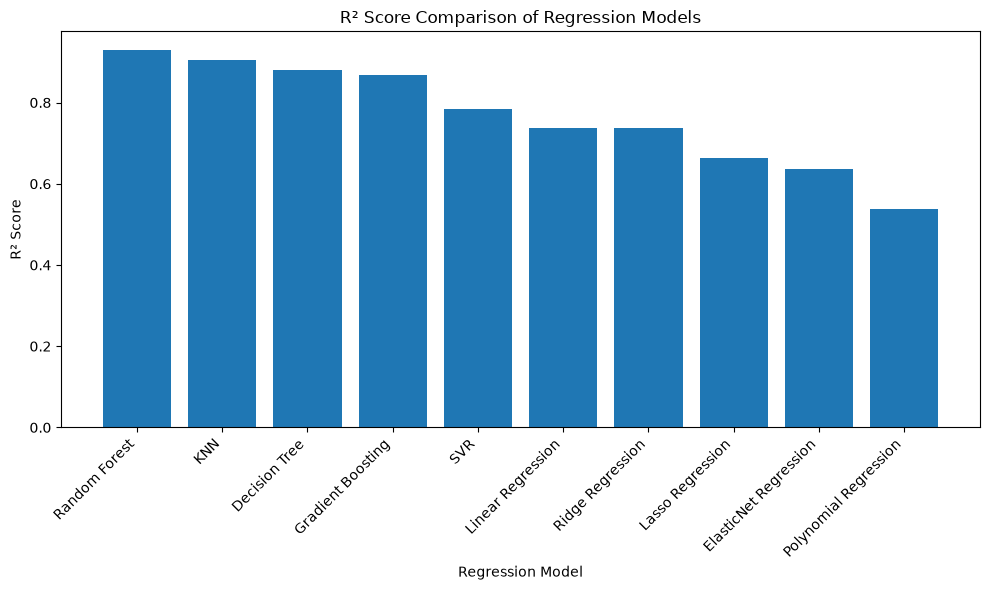

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(results_df["Model"], results_df["R2"])

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison of Regression Models")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation

Random Forest achieved the highest R² score of 0.929 among the evaluated regression models.
It also achieved the lowest RMSE and MAE, indicating that it provides the best baseline performance for predicting critical temperature.